### Visualizations

In [2]:
import pandas as pd
import calmap
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from pylab import rcParams
import folium
from polygon_geohasher.polygon_geohasher import geohashes_to_polygon
import geohash as pgh
import networkx as nx

In [3]:
import os 
os.getcwd()
os.chdir('../deep_models')
from utils import build_df_sparse, build_df

In [4]:
# SELECT PRECISION TO BE USED FOR ALL THE FOLLOWING ANALYSIS: 
# the precision is used to create a grid dividing the city into equally-sized blocks or cells,
# the greatest the precision, the lower the dimension of the blocks

# EXAMPLES:
# precision = 5 divides the city into 6 blocks with dimension <= 4.89km x 4.89km
# precision = 6 divides the city into 40 blocks with dimensions <= 1.22km x 0.61km

precision = 5 

In [5]:
final_df = build_df_sparse(precision=precision, freq='24H')

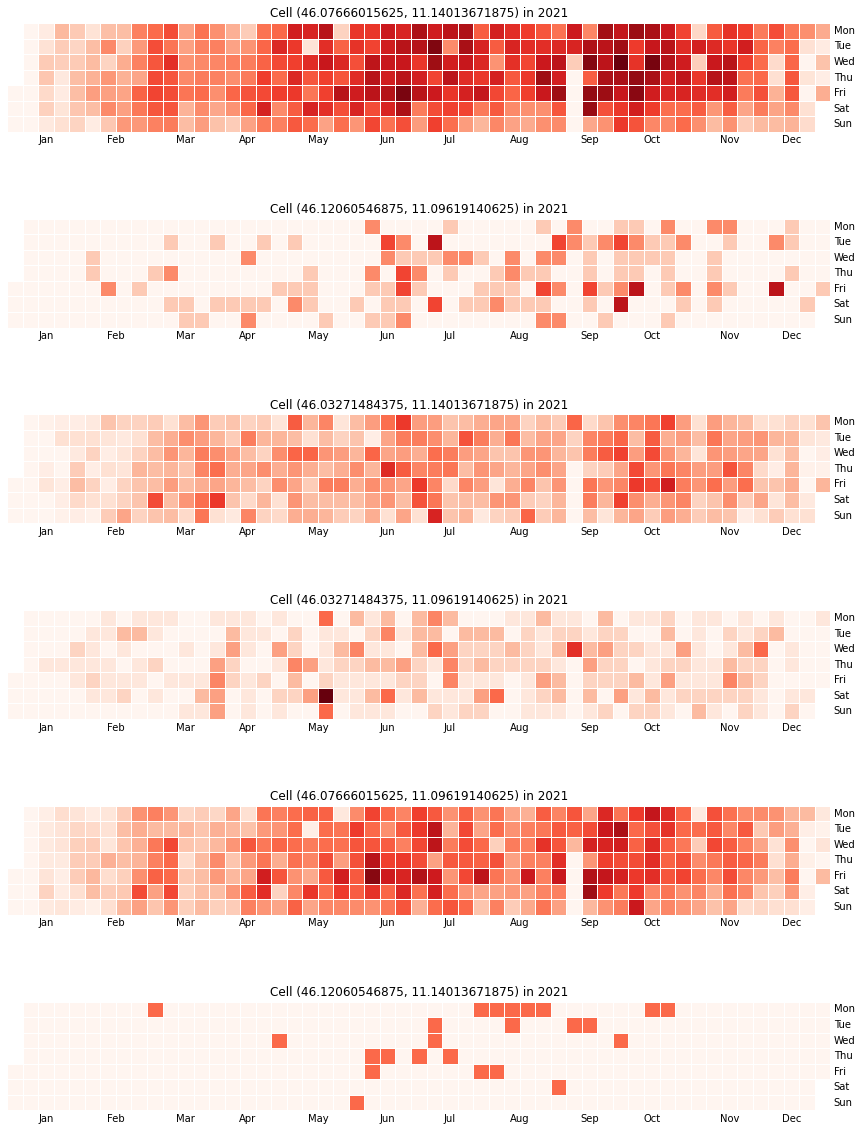

In [9]:
rcParams['figure.figsize'] = 20, 20
# one calendar plot for the year 2021, one for cell
fig, axis = plt.subplots(final_df.gh.nunique())

n=0
for g in final_df.gh.unique():
    gh_df = final_df[final_df.gh==g][['trips_count']]
    axis[n].set_title('Cell '+str(g)+' in 2021')
    calmap.yearplot(gh_df['trips_count'], year=2021, ax=axis[n])
    n=n+1
fig.subplots_adjust(hspace=0.8)

(<Figure size 1584x720 with 3 Axes>,
 array([<AxesSubplot:ylabel='2020'>, <AxesSubplot:ylabel='2021'>,
        <AxesSubplot:ylabel='2022'>], dtype=object))

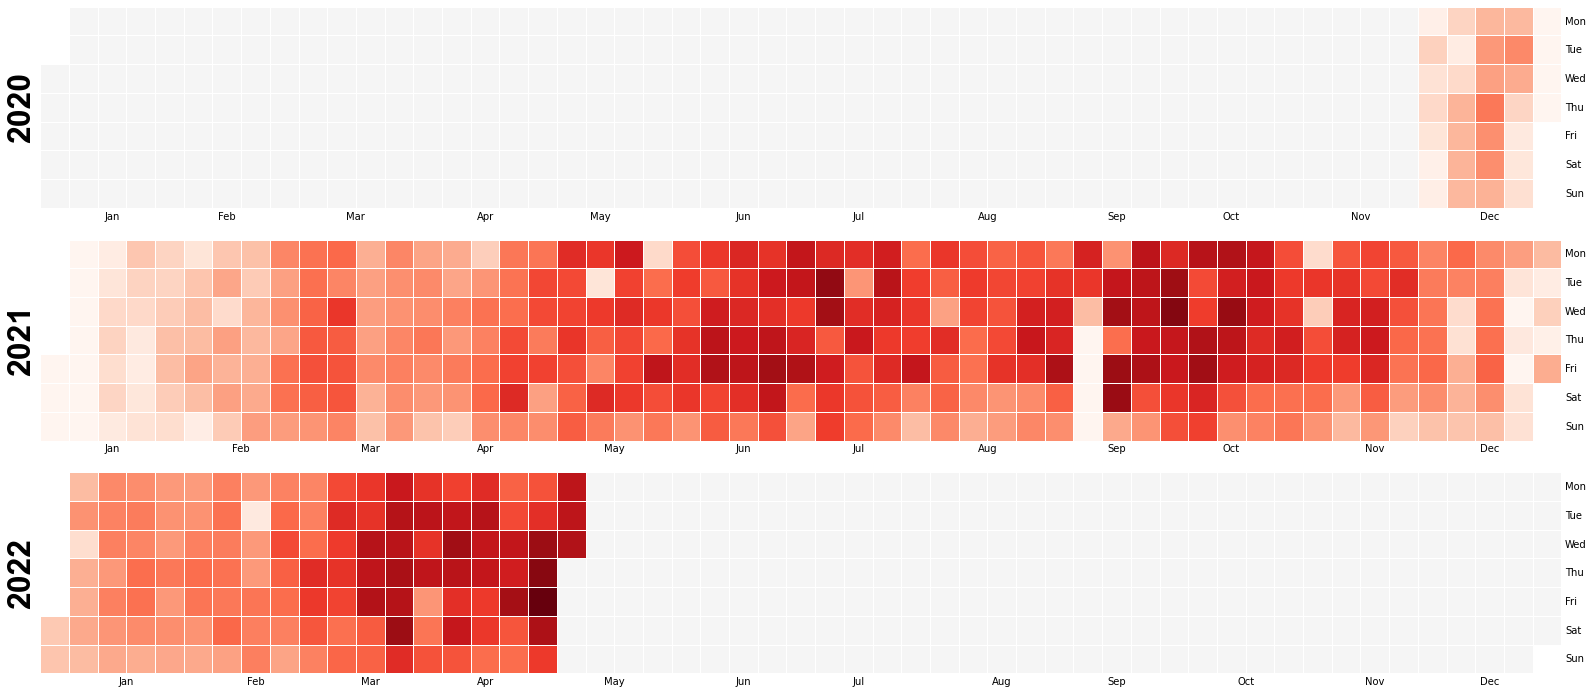

In [10]:
rcParams['figure.figsize'] = 22, 10
# calmap.yearplot(final_df['trips_count'], year=2021)
# calendar plot for counts of trips by day in the whole city
calmap.calendarplot(final_df['trips_count'], yearlabel_kws={'color':'black'})

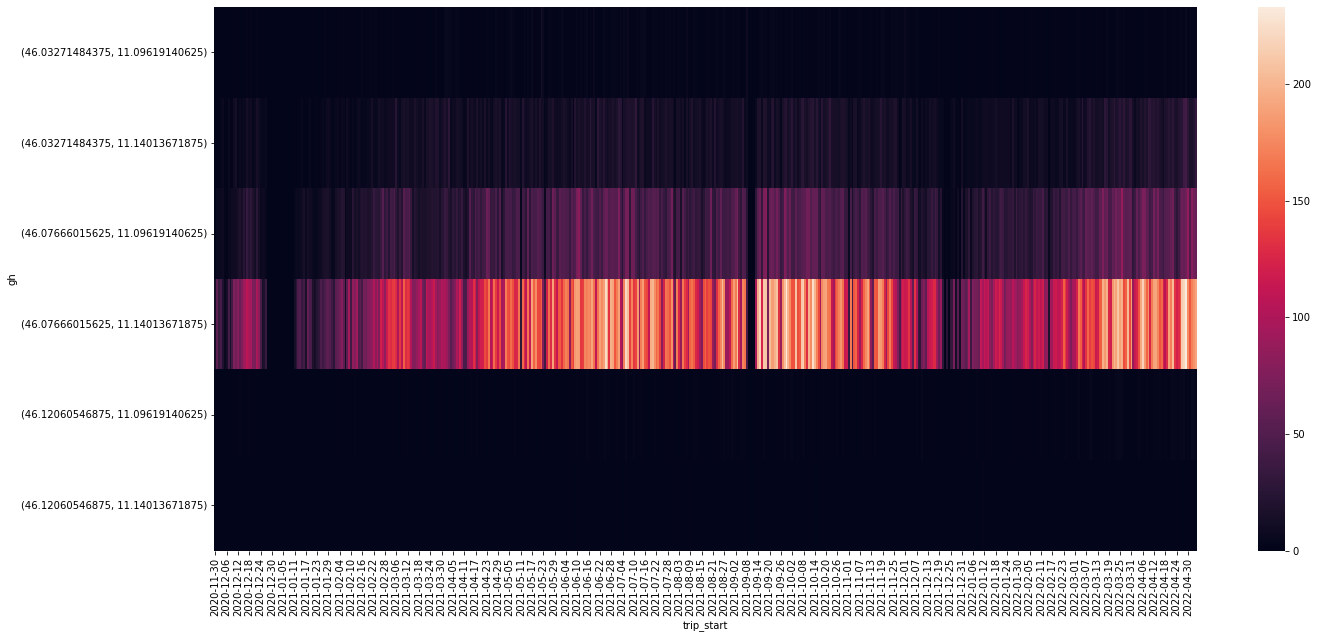

In [11]:
# counts of trip by day by cell
cnt_by_gh = final_df.reset_index()
cnt_by_gh['trip_start'] = cnt_by_gh['trip_start'].dt.tz_localize(None)
cnt_by_gh['trip_start'] = pd.to_datetime(cnt_by_gh['trip_start'], format = '%Y-%M-%d')
cnt_by_gh['trip_start'] = cnt_by_gh.trip_start.astype('str')
cnt_by_gh = cnt_by_gh.pivot("gh", "trip_start", "trips_count")
ax = sns.heatmap(cnt_by_gh)

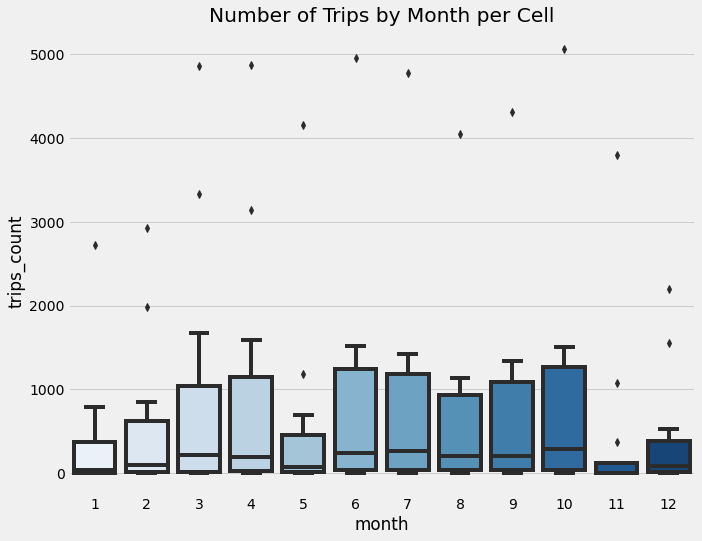

In [12]:
final_df = build_df_sparse(precision=precision, freq='M') # freq = monthly -> count of trips per cell by month

# trips by month
plt.style.use('fivethirtyeight')
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=final_df, x='month', y='trips_count', palette='Blues')
ax.set_title('Number of Trips by Month per Cell')
plt.show()

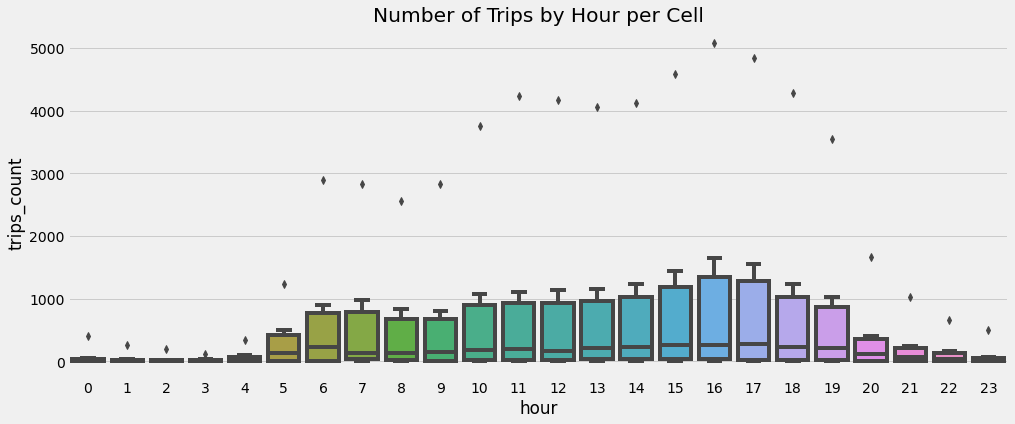

In [13]:
# trips by hour
final_df = build_df_sparse(precision=precision, freq='H')
df_agg_gh_h = final_df.groupby(['hour', 'gh']).aggregate({'trips_count':'sum'}).reset_index() # count of trips by hour by cell
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_agg_gh_h, x='hour', y='trips_count').set_title('Number of Trips by Hour per Cell')
plt.show()

**Cluster Map**: show all trips origin, clustered together based on their spatial proximity

In [1]:
import folium
from  folium import plugins

In [4]:
df =  pd.read_parquet('C:/Users/luisa/Desktop/thesis_project/data/tripsv3_augmented.parquet')

In [5]:
# zoom level
m = folium.Map(location = [46.06, 11.14] , zoom_start = 14)


# instantiate a mark cluster object for the datapoints in the dataframe
datapoints = plugins.MarkerCluster().add_to(m)


# loop through the dataframe and add each data point to the mark cluster
for lat, lng in zip(df.trip_origin_latitude, df.trip_origin_longitude):
    folium.Marker(
        location=[lat, lng],
        icon=None
    ).add_to(datapoints)


# display map
# m

In [50]:
m.save('C:/Users/luisa/Desktop/thesis_project/images/others/cluster_map.html')

**Geohash representation**

In [7]:
df = build_df_sparse(precision=precision, freq='H')

In [10]:
# encode to get geohash codes
geoh = [pgh.encode(gh[0], gh[1], precision) for gh in df.gh.unique()]


# create list of lists, each list must contain a single polygon/geohash
geoh_ll = [[g] for g in geoh]
# get polygons from geohashes
polygons=[]
for el in geoh_ll:
    polygons.append(geohashes_to_polygon(el))

In [12]:
m = folium.Map(location=[46.07, 11.12], zoom_start=12, tiles='CartoDB positron')

for poly in range(len(polygons)):
    geo_j = folium.GeoJson(data=polygons[poly], style_function=lambda x: {'fillColor': 'orange'})
    folium.Popup(geoh[poly]).add_to(geo_j)
    geo_j.add_to(m)
# m

In [18]:
m.save('C:/Users/luisa/Desktop/thesis_project/images/others/geohash_map.html')

In [13]:
# associate numbers to cells 
df = df.reset_index()
all_gh = df.gh.unique()
gh_to_int = {gh_id:i for i, gh_id in enumerate(all_gh)}
int_to_gh = {i:gh_id for i, gh_id in enumerate(all_gh)}

In [23]:
# ADD NUMBER OF CELLS TO THE MAP

m = folium.Map(location=[46.07, 11.12], zoom_start=12, tiles='CartoDB positron')

for poly in range(len(polygons)):
    geo_j = folium.GeoJson(data=polygons[poly], style_function=lambda x: {'fillColor': 'orange'})
    folium.Popup(geoh[poly]).add_to(geo_j)

    from folium.features import DivIcon
    cell = gh_to_int[tuple((polygons[poly].centroid.y, polygons[poly].centroid.x))]
    folium.map.Marker(
    [polygons[poly].centroid.y + 0.003, polygons[poly].centroid.x - 0.0025],
    icon=DivIcon(
        icon_anchor=(0,0),
        html='<div style="font-size: 13pt">%s</div>' % cell,
        )
    ).add_to(m)


    geo_j.add_to(m)

# m
# m.save('C:/Users/luisa/Desktop/thesis_project/imgs/others/geohash_map_with_numbers.html')

In [26]:
# HIGHLIGHT BEST CELLS 

m = folium.Map(location=[46.07, 11.12], zoom_start=12, tiles='CartoDB positron')
best_cells = [0, 3, 11, 14, 16, 17, 26, 35, 37, 8, 24, 28]

for poly in range(len(polygons)):
    if int(poly) in best_cells:
        geo_j = folium.GeoJson(data=polygons[poly], style_function=lambda x: {'fillColor': 'red'})
    else:
        geo_j = folium.GeoJson(data=polygons[poly], style_function=lambda x: {'fillColor': 'orange'})
    folium.Popup(geoh[poly]).add_to(geo_j)

    from folium.features import DivIcon
    cell = gh_to_int[tuple((polygons[poly].centroid.y, polygons[poly].centroid.x))]
    folium.map.Marker(
    [polygons[poly].centroid.y + 0.003, polygons[poly].centroid.x - 0.0025],
    icon=DivIcon(
        icon_anchor=(0,0),
        html='<div style="font-size: 13pt">%s</div>' % cell,
        )
    ).add_to(m)


    geo_j.add_to(m)

# m
# m.save('C:/Users/luisa/Desktop/thesis_project/imgs/others/map_best_cells.html')

**Draw network**

In [22]:
# get all neighbours cells, so that we can put a connection among them in the graph/adjacency matrix
edges = []
for current_gh in geoh:
    for neighbor in pgh.neighbors(current_gh):
        if neighbor in geoh: # check that the neighbor is not outside the study area of Trento
            edges.append((current_gh, neighbor, {'len':str(100)}))

# build adjacency matrix based on cells neighbouring
d = {'nodes':geoh,
     'edges':edges}

g = nx.DiGraph()
g.add_nodes_from(d['nodes'])
g.add_edges_from(d['edges'])

adjacency_matrix = nx.to_pandas_adjacency(g)

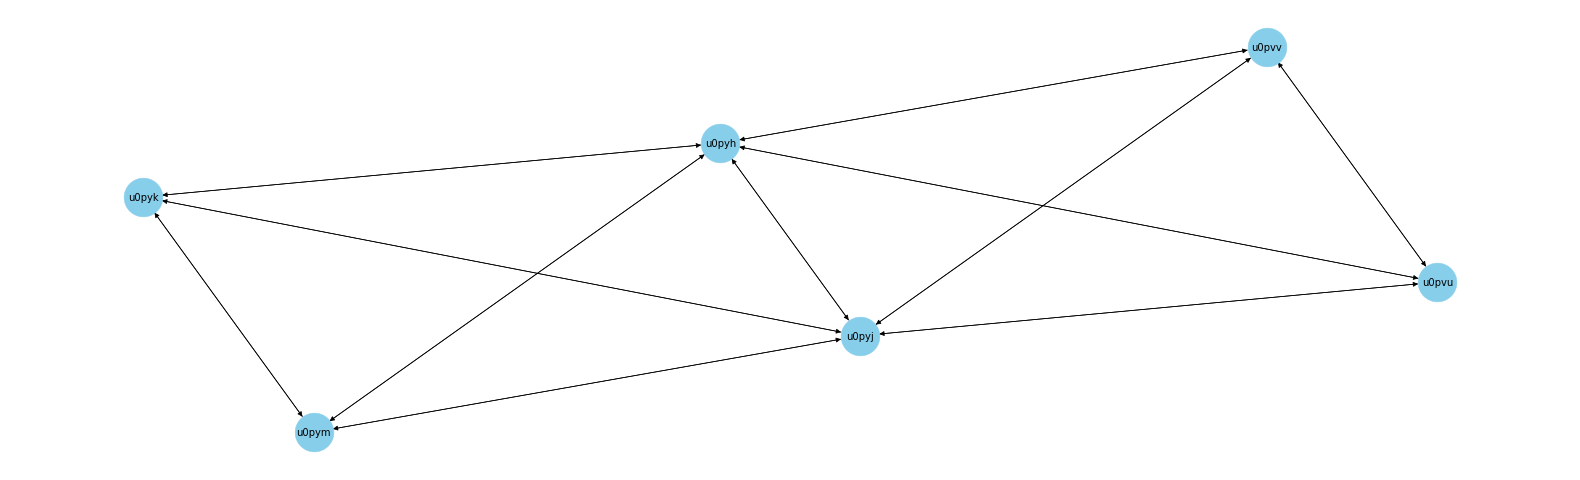

In [23]:
# draw cells network
fig, ax = plt.subplots(figsize=(25,8))
nx.draw(g, nx.kamada_kawai_layout(g), with_labels=True, node_size=1500, font_size=10, width=0.75, node_color='skyblue')
# plt.savefig('C:/Users/luisa/Desktop/thesis_project/images/others/cells_network.png')